# 08 — Results Visualisation

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**  
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 1.0

---

## Objectives

Produce **publication-quality integrated figures** for the dissertation that narrate the full pipeline:

1. **Figure 08a — Event Landscape** — event volume, type distribution, sentiment over time, and president-level breakdown
2. **Figure 08b — Causal Evidence** — CAR distributions, DoWhy estimates with CI, sentiment-CAR scatter, regime interaction
3. **Figure 08c — Predictive Pipeline** — feature importance by group, model comparison, SHAP top drivers
4. **Figure 08d — Full-Period Dashboard** — integrated timeline: SPY price + VIX + events + model signal + cumulative strategy return

**Inputs:** All processed parquets from phases 1–7  
**Outputs:** `08a`–`08d` PNG figures (300 dpi, dissertation-ready)

In [1]:
import os, sys, warnings, pickle, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
FIGS   = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── Publication plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':          150,
    'savefig.dpi':         300,       # dissertation quality
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.alpha':          0.25,
    'grid.linestyle':      '--',
    'font.family':         'sans-serif',
    'font.size':           10,
    'axes.titlesize':      11,
    'axes.labelsize':      10,
    'legend.fontsize':     8,
    'xtick.labelsize':     8,
    'ytick.labelsize':     8,
})

# ── Colour palette (consistent across all figures) ────────────────────────────
C = {
    'monetary':    '#1f4e79',
    'geopolitical':'#c55a11',
    'regulatory':  '#70ad47',
    'trade':       '#7030a0',
    'energy':      '#d4a017',
    'other':       '#95a5a6',
    'positive':    '#27ae60',
    'negative':    '#e74c3c',
    'neutral':     '#95a5a6',
    'spy':         '#2c3e50',
    'vix':         '#e74c3c',
    'lasso':       '#1f4e79',
    'xgb':         '#c55a11',
    'lgb':         '#70ad47',
    'strategy':    '#7030a0',
    'bh':          '#95a5a6',
}

EVENT_ORDER = ['monetary','geopolitical','regulatory','trade','energy']

print('✓ Imports complete — publication style active')

✓ Imports complete — publication style active


---
## Section 1 — Load All Data

In [2]:
# ── Phase 3 outputs ────────────────────────────────────────────────────────────
events_df   = pd.read_parquet(PROC / 'events_tagged.parquet')
sent_df     = pd.read_parquet(PROC / 'daily_sentiment.parquet')
events_df['date'] = pd.to_datetime(events_df['date'])
sent_df['date']   = pd.to_datetime(sent_df['date'])

# ── Phase 4 outputs ────────────────────────────────────────────────────────────
car_df     = pd.read_parquet(PROC / 'car_results.parquet')
causal_df  = pd.read_parquet(PROC / 'causal_estimates.parquet')
car_df['date'] = pd.to_datetime(car_df['date'])

# ── Phase 5 outputs ────────────────────────────────────────────────────────────
feat_meta  = pd.read_parquet(PROC / 'feature_metadata.parquet')
feat_df    = pd.read_parquet(PROC / 'model_features.parquet')
feat_df['date'] = pd.to_datetime(feat_df['date'])

# ── Phase 6 outputs ────────────────────────────────────────────────────────────
preds_df   = pd.read_parquet(PROC / 'test_predictions.parquet')
shap_df    = pd.read_parquet(PROC / 'shap_values.parquet')
comp_df    = pd.read_parquet(PROC / 'model_comparison.parquet')
preds_df['date'] = pd.to_datetime(preds_df['date'])
shap_df['date']  = pd.to_datetime(shap_df['date'])

# ── Phase 7 outputs ────────────────────────────────────────────────────────────
eval_df    = pd.read_parquet(PROC / 'evaluation_summary.parquet')
with open(MODELS / 'model_metadata.json') as f:
    meta = json.load(f)

BEST_MODEL  = meta['best_model']
TRAIN_CUT   = meta['train_cutoff']
SHAP_FEATS  = [c for c in shap_df.columns if c != 'date']
SELECTED    = feat_meta[feat_meta['selected']]['feature'].tolist()

# ── Convenience arrays ─────────────────────────────────────────────────────────
y_true  = preds_df['actual'].values
y_best  = preds_df['best_pred'].values
y_lasso = preds_df['lasso_pred'].values
y_xgb   = preds_df['xgb_pred'].values
y_lgb   = preds_df['lgb_pred'].values
dates   = preds_df['date'].values

print(f'Events       : {len(events_df):,}')
print(f'CAR records  : {len(car_df):,}')
print(f'Test days    : {len(preds_df):,}')
print(f'Best model   : {BEST_MODEL}')
print('✓ All data loaded')

Events       : 180,594
CAR records  : 1,796
Test days    : 750
Best model   : LASSO
✓ All data loaded


---
## Figure 08a — Event Landscape (2015–2025)

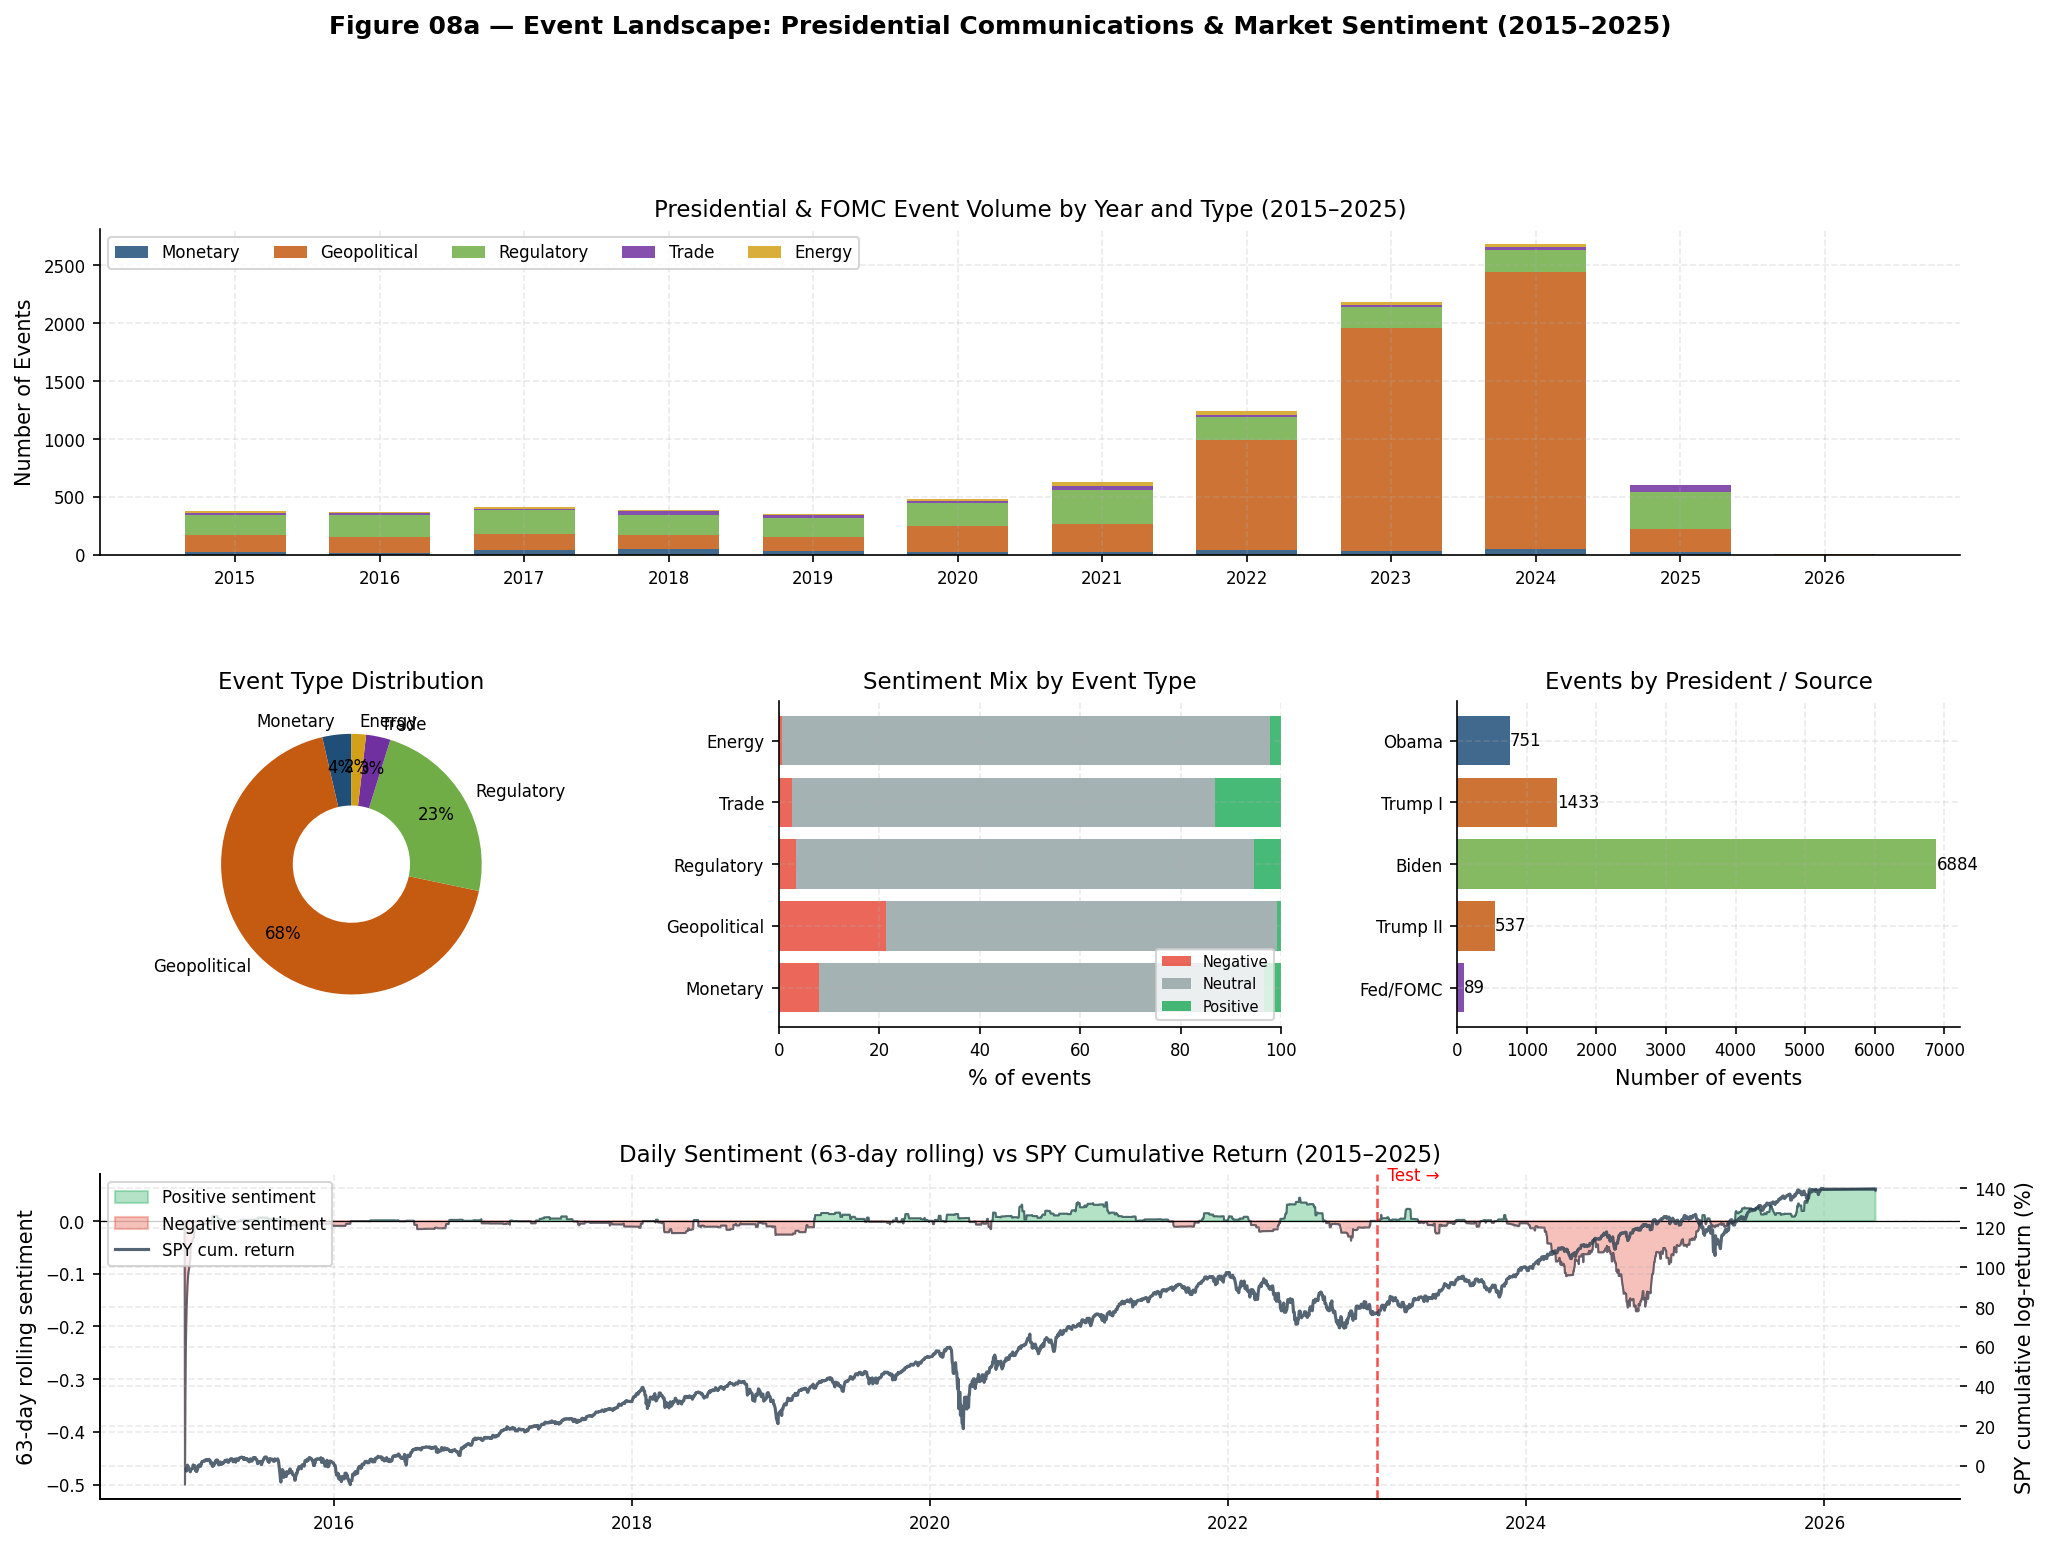

✓ Saved 08a_event_landscape.png


In [3]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1 (top, full width): Event volume over time by type ─────────────────
ax1 = fig.add_subplot(gs[0, :])
yearly = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .assign(year=events_df['date'].dt.year)
    .groupby(['year','event_type'])
    .size().unstack(fill_value=0)
)
# Reorder columns
yearly = yearly.reindex(columns=[e for e in EVENT_ORDER if e in yearly.columns])
bottom = np.zeros(len(yearly))
for col in yearly.columns:
    ax1.bar(yearly.index, yearly[col], bottom=bottom,
            color=C[col], alpha=0.85, label=col.capitalize(), width=0.7)
    bottom += yearly[col].values
ax1.set_ylabel('Number of Events')
ax1.set_title('Presidential & FOMC Event Volume by Year and Type (2015–2025)')
ax1.legend(loc='upper left', ncol=5, fontsize=8)
ax1.set_xticks(yearly.index)

# ── Panel 2 (mid-left): Event type distribution (donut) ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['event_type'].value_counts().reindex(EVENT_ORDER).fillna(0)
)
wedges, texts, autotexts = ax2.pie(
    type_counts.values,
    labels=[t.capitalize() for t in type_counts.index],
    colors=[C[t] for t in type_counts.index],
    autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55)
)
for at in autotexts: at.set_fontsize(8)
ax2.set_title('Event Type Distribution')

# ── Panel 3 (mid-centre): Sentiment distribution by event type ───────────────
ax3 = fig.add_subplot(gs[1, 1])
sent_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    .groupby(['event_type','sentiment_label'])
    .size().unstack(fill_value=0)
)
sent_counts = sent_counts.reindex(index=EVENT_ORDER)
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100
bottom_s = np.zeros(len(sent_pct))
for sent_label, col in [('negative', C['negative']), ('neutral', C['neutral']), ('positive', C['positive'])]:
    if sent_label in sent_pct.columns:
        ax3.barh([e.capitalize() for e in sent_pct.index],
                 sent_pct[sent_label], left=bottom_s,
                 color=col, alpha=0.85, label=sent_label.capitalize())
        bottom_s += sent_pct[sent_label].values
ax3.set_xlabel('% of events')
ax3.set_title('Sentiment Mix by Event Type')
ax3.legend(loc='lower right', fontsize=7)
ax3.set_xlim(0, 100)

# ── Panel 4 (mid-right): Events by president ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pres_short = {
    'Barack Obama':              'Obama',
    'Donald J. Trump (1st Term)':'Trump I',
    'Joseph R. Biden, Jr.':      'Biden',
    'Donald J. Trump (2nd Term)':'Trump II',
    'Federal Reserve':           'Fed/FOMC',
}
pres_counts = (
    events_df[events_df['event_type'].isin(EVENT_ORDER)]
    ['president'].map(pres_short).value_counts()
)
pres_order = ['Obama','Trump I','Biden','Trump II','Fed/FOMC']
pres_counts = pres_counts.reindex([p for p in pres_order if p in pres_counts.index])
PALETTE_PRES = ['#1f4e79','#c55a11','#70ad47','#c55a11','#7030a0']
ax4.barh(pres_counts.index[::-1], pres_counts.values[::-1],
         color=PALETTE_PRES[:len(pres_counts)][::-1],
         alpha=0.85)
for i, val in enumerate(pres_counts.values[::-1]):
    ax4.text(val + 5, i, str(val), va='center', fontsize=8)
ax4.set_xlabel('Number of events')
ax4.set_title('Events by President / Source')

# ── Panel 5 (bottom, full width): Rolling daily sentiment vs SPY ─────────────
ax5 = fig.add_subplot(gs[2, :])
daily_overall = sent_df.set_index('date')['overall_mean_sentiment'].fillna(0)
rolling_sent  = daily_overall.rolling(63, min_periods=1).mean()
# SPY log-returns cumulative
spy_ret = feat_df.set_index('date')['log_return']
spy_cum = (spy_ret.cumsum() * 100).reindex(rolling_sent.index, method='ffill')

ax5b = ax5.twinx()
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent >= 0, alpha=0.35, color=C['positive'], label='Positive sentiment')
ax5.fill_between(rolling_sent.index, rolling_sent, 0,
                 where=rolling_sent < 0, alpha=0.35, color=C['negative'], label='Negative sentiment')
ax5.plot(rolling_sent.index, rolling_sent, linewidth=1, color='#2c3e50', alpha=0.7)
ax5b.plot(spy_cum.index, spy_cum.values, color=C['spy'], linewidth=1.5, alpha=0.8, label='SPY cum. return')
ax5.set_ylabel('63-day rolling sentiment')
ax5b.set_ylabel('SPY cumulative log-return (%)')
ax5.set_title('Daily Sentiment (63-day rolling) vs SPY Cumulative Return (2015–2025)')
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax5.axhline(0, color='black', linewidth=0.6)
# Mark train/test split
ax5.axvline(pd.Timestamp(TRAIN_CUT), color='red', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Train/test split')
ax5.text(pd.Timestamp(TRAIN_CUT), ax5.get_ylim()[1] * 0.85, '  Test →',
         color='red', fontsize=8)

plt.suptitle('Figure 08a — Event Landscape: Presidential Communications & Market Sentiment (2015–2025)',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(FIGS / '08a_event_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08a_event_landscape.png')

---
## Figure 08b — Causal Evidence

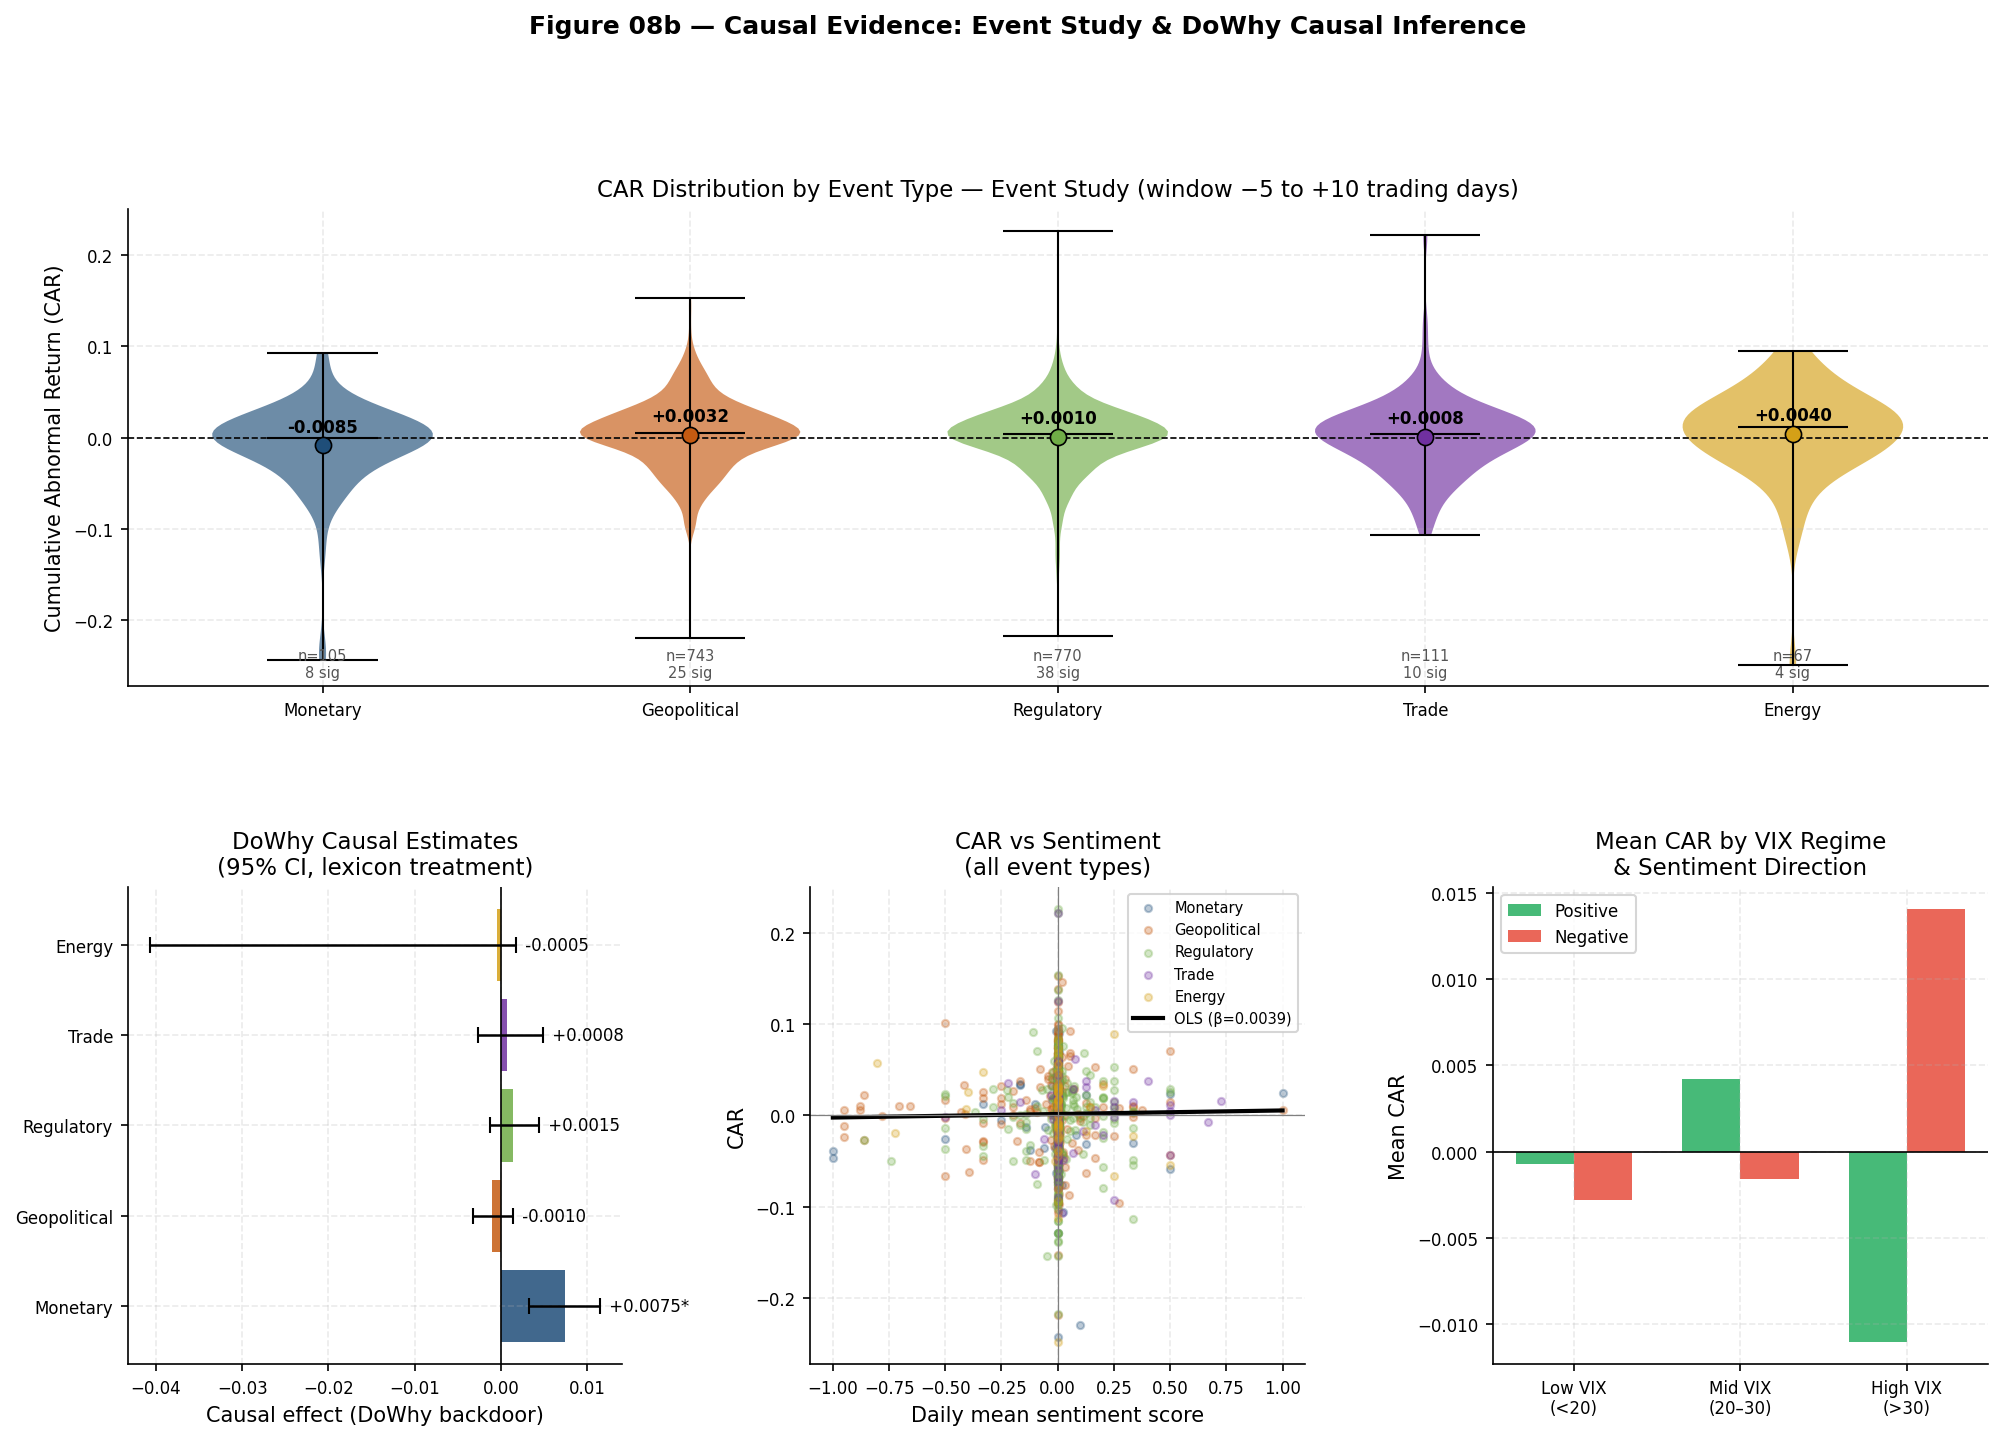

✓ Saved 08b_causal_evidence.png


In [4]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Panel 1: CAR distribution by event type (violin) ─────────────────────────
ax1 = fig.add_subplot(gs[0, :])
car_plot = car_df[car_df['event_type'].isin(EVENT_ORDER)].copy()
car_plot['event_type_label'] = car_plot['event_type'].str.capitalize()
order_labels = [e.capitalize() for e in EVENT_ORDER]

vp = ax1.violinplot(
    [car_plot[car_plot['event_type'] == et]['car'].dropna().values for et in EVENT_ORDER],
    positions=range(len(EVENT_ORDER)),
    showmedians=True, showextrema=True, widths=0.6
)
for pc, et in zip(vp['bodies'], EVENT_ORDER):
    pc.set_facecolor(C[et])
    pc.set_alpha(0.65)
for part in ['cmedians','cmaxes','cmins','cbars']:
    vp[part].set_color('black')
    vp[part].set_linewidth(1)

# Mean CAR dots
for i, et in enumerate(EVENT_ORDER):
    grp = car_plot[car_plot['event_type'] == et]['car'].dropna()
    mean_car = grp.mean()
    ax1.scatter(i, mean_car, s=60, color=C[et], zorder=5, edgecolors='black', linewidths=0.8)
    ax1.text(i, mean_car + 0.015, f'{mean_car:+.4f}', ha='center', fontsize=8, fontweight='bold')

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(range(len(EVENT_ORDER)))
ax1.set_xticklabels(order_labels)
ax1.set_ylabel('Cumulative Abnormal Return (CAR)')
ax1.set_title('CAR Distribution by Event Type — Event Study (window −5 to +10 trading days)')

# Significance counts
for i, et in enumerate(EVENT_ORDER):
    grp = car_plot[car_plot['event_type'] == et]
    n_sig = grp['significant'].sum() if 'significant' in grp.columns else 0
    n_tot = len(grp)
    ax1.text(i, ax1.get_ylim()[0] + 0.01,
             f'n={n_tot}\n{n_sig} sig', ha='center', fontsize=7, color='#555555')

# ── Panel 2: DoWhy causal estimates with CI ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
lex_est = causal_df[causal_df['sentiment_method'] == 'lexicon'].copy()
lex_est = lex_est.set_index('event_type').reindex(EVENT_ORDER).dropna(subset=['causal_effect'])
y_pos = range(len(lex_est))
ax2.barh(y_pos, lex_est['causal_effect'].values,
         xerr=[
             lex_est['causal_effect'].values - lex_est['ci_lower'].values,
             lex_est['ci_upper'].values - lex_est['causal_effect'].values,
         ],
         color=[C[et] for et in lex_est.index],
         alpha=0.85, capsize=4, error_kw=dict(linewidth=1.2))
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([e.capitalize() for e in lex_est.index])
ax2.set_xlabel('Causal effect (DoWhy backdoor)')
ax2.set_title('DoWhy Causal Estimates\n(95% CI, lexicon treatment)')
for i, (et, row) in enumerate(lex_est.iterrows()):
    sig_marker = '*' if row['ci_lower'] > 0 or row['ci_upper'] < 0 else ''
    ax2.text(row['ci_upper'] + 0.0005, i, f" {row['causal_effect']:+.4f}{sig_marker}",
             va='center', fontsize=8)

# ── Panel 3: CAR vs sentiment scatter ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for et in EVENT_ORDER:
    grp = car_df[car_df['event_type'] == et].dropna(subset=['car','overall_mean_sentiment'])
    if len(grp) < 5:
        continue
    ax3.scatter(grp['overall_mean_sentiment'], grp['car'],
                alpha=0.3, s=12, color=C[et], label=et.capitalize())
# OLS line on all events
all_grp = car_df.dropna(subset=['car','overall_mean_sentiment'])
m, b    = np.polyfit(all_grp['overall_mean_sentiment'], all_grp['car'], 1)
x_range = np.linspace(all_grp['overall_mean_sentiment'].min(),
                      all_grp['overall_mean_sentiment'].max(), 100)
ax3.plot(x_range, m * x_range + b, 'k-', linewidth=2, label=f'OLS (β={m:.4f})')
ax3.axhline(0, color='grey', linewidth=0.6)
ax3.axvline(0, color='grey', linewidth=0.6)
ax3.set_xlabel('Daily mean sentiment score')
ax3.set_ylabel('CAR')
ax3.set_title('CAR vs Sentiment\n(all event types)')
ax3.legend(fontsize=7)

# ── Panel 4: CAR by VIX regime & sentiment direction ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
car_df['vix_regime_label'] = pd.cut(
    car_df['vix'],
    bins=[0, 20, 30, 100],
    labels=['Low VIX\n(<20)', 'Mid VIX\n(20–30)', 'High VIX\n(>30)']
)
car_df['sent_direction'] = car_df['sentiment_numeric'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
regime_sent = (
    car_df[car_df['sent_direction'].isin(['Positive','Negative'])]
    .groupby(['vix_regime_label','sent_direction'])['car']
    .mean().unstack()
)
if not regime_sent.empty:
    x_pos = np.arange(len(regime_sent))
    w = 0.35
    for j, (col, clr) in enumerate([('Positive', C['positive']), ('Negative', C['negative'])]):
        if col in regime_sent.columns:
            bars = ax4.bar(x_pos + j * w, regime_sent[col], w,
                           color=clr, alpha=0.85, label=col)
    ax4.set_xticks(x_pos + w/2)
    ax4.set_xticklabels(regime_sent.index)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_ylabel('Mean CAR')
    ax4.set_title('Mean CAR by VIX Regime\n& Sentiment Direction')
    ax4.legend(fontsize=8)

plt.suptitle('Figure 08b — Causal Evidence: Event Study & DoWhy Causal Inference',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(FIGS / '08b_causal_evidence.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08b_causal_evidence.png')

---
## Figure 08c — Predictive Pipeline

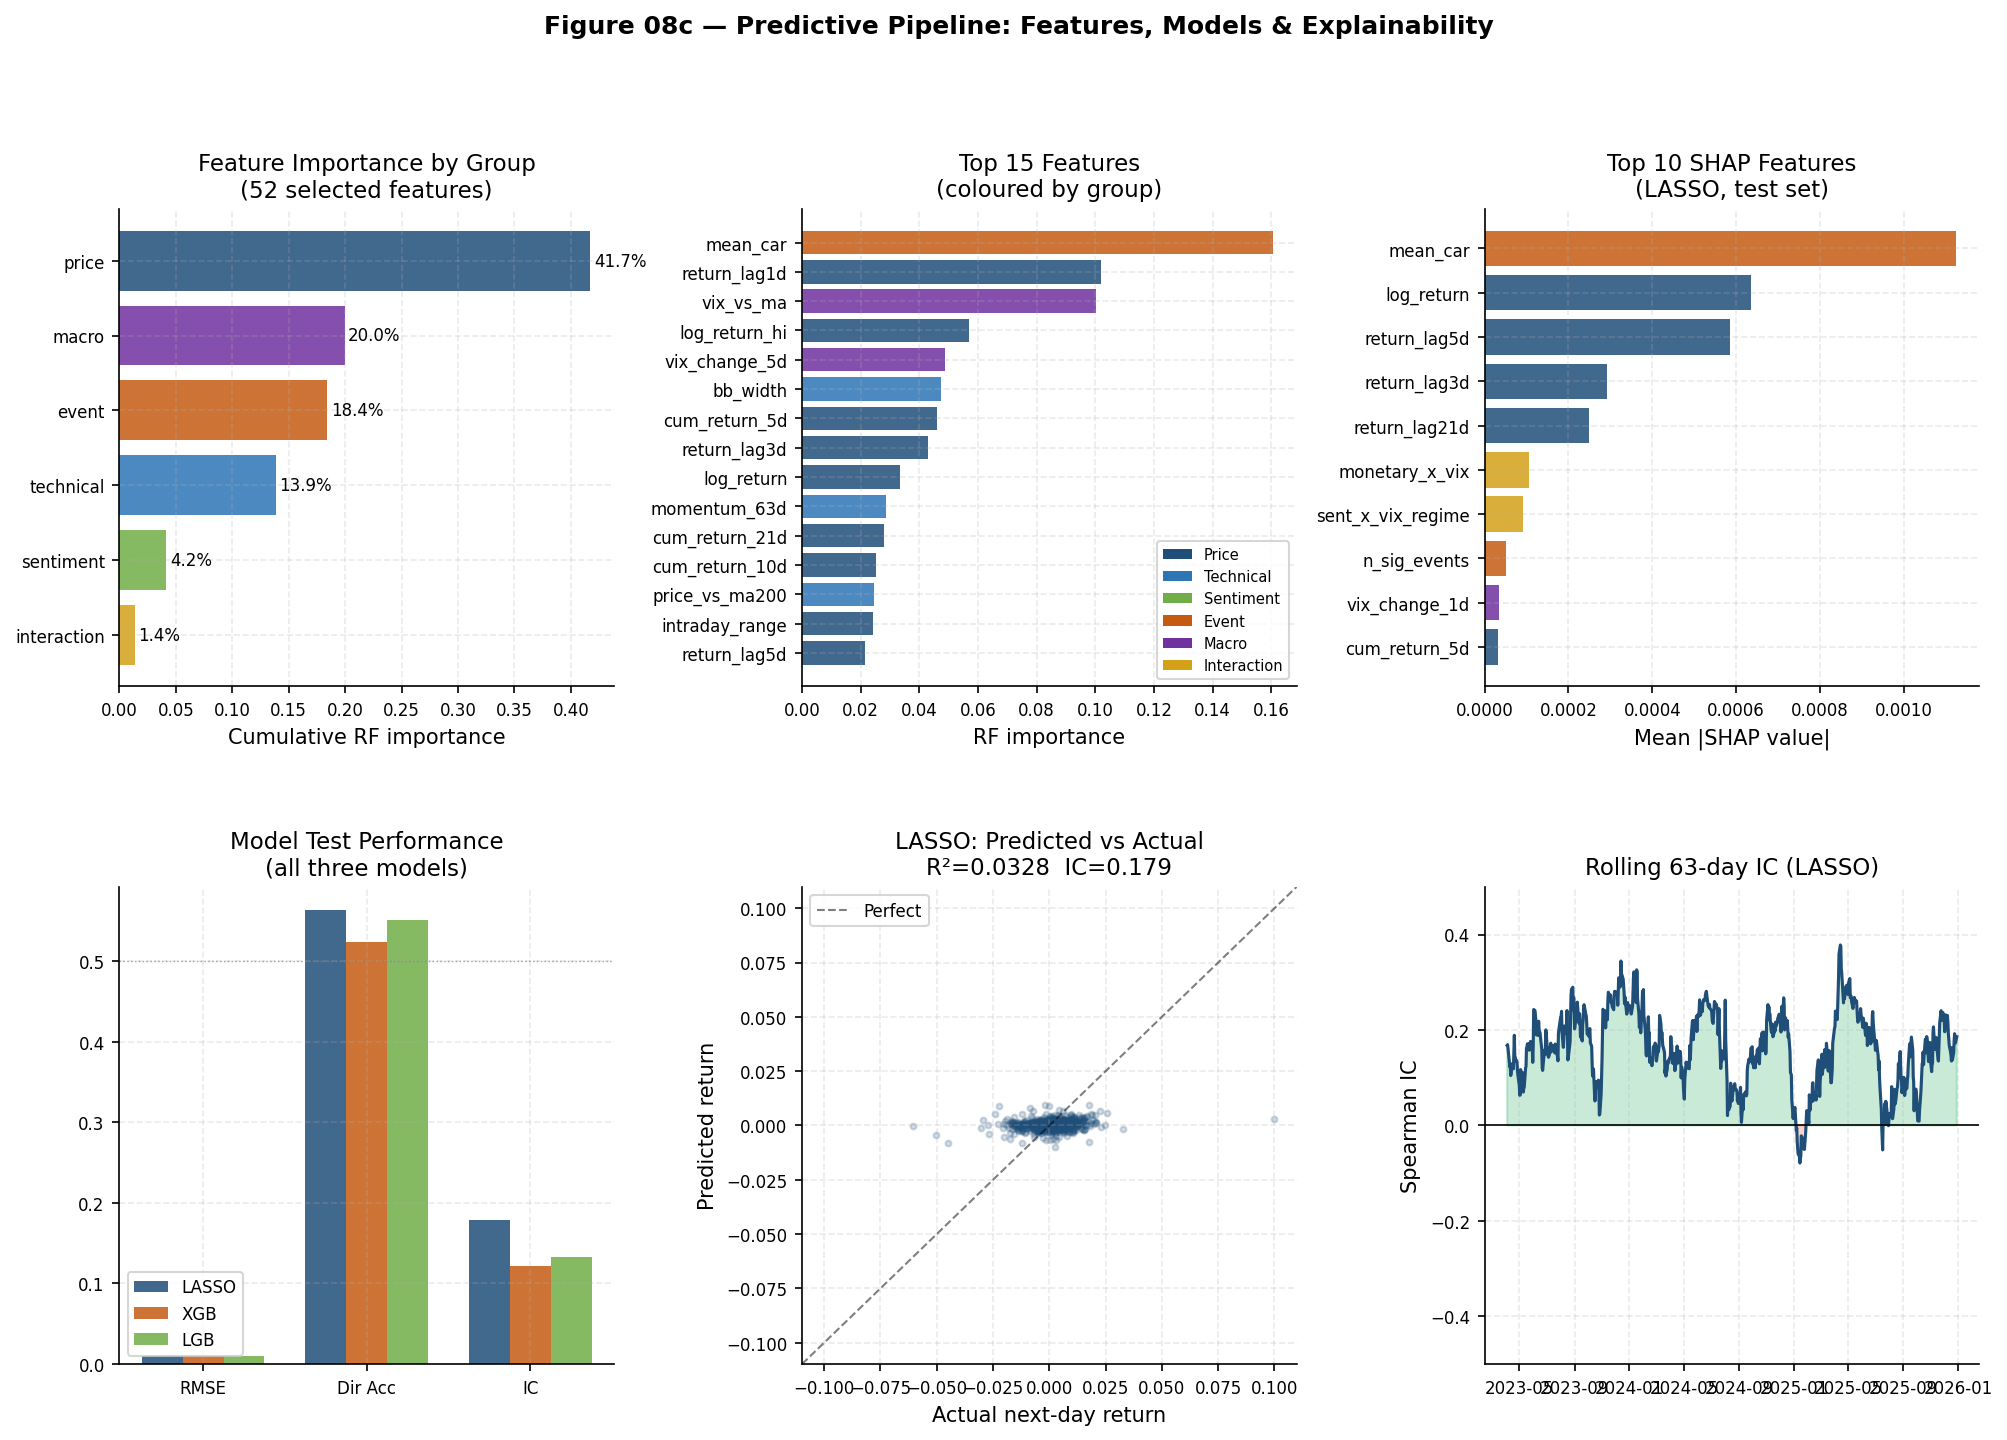

✓ Saved 08c_predictive_pipeline.png


In [5]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

GROUP_COLOURS = {
    'price':     '#1f4e79',
    'technical': '#2e75b6',
    'sentiment': '#70ad47',
    'event':     '#c55a11',
    'macro':     '#7030a0',
    'interaction':'#d4a017',
}

# ── Panel 1: Feature importance by group (stacked bar) ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
selected_feat = feat_meta[feat_meta['selected']].copy()
group_imp = (
    selected_feat.groupby('group')['importance']
    .sum().sort_values(ascending=False)
)
bar_colours = [GROUP_COLOURS.get(g, '#888') for g in group_imp.index]
bars = ax1.barh(group_imp.index[::-1], group_imp.values[::-1],
                color=bar_colours[::-1], alpha=0.85)
for bar, val in zip(bars, group_imp.values[::-1]):
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax1.set_xlabel('Cumulative RF importance')
ax1.set_title('Feature Importance by Group\n(52 selected features)')

# ── Panel 2: Top 15 individual features ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top15 = selected_feat.nlargest(15, 'importance')
feat_colours = [GROUP_COLOURS.get(g, '#888') for g in top15['group']]
ax2.barh(top15['feature'][::-1], top15['importance'][::-1],
         color=feat_colours[::-1], alpha=0.85)
ax2.set_xlabel('RF importance')
ax2.set_title('Top 15 Features\n(coloured by group)')
# Legend
legend_els = [Patch(facecolor=c, label=g.capitalize()) for g, c in GROUP_COLOURS.items()
              if g in selected_feat['group'].values]
ax2.legend(handles=legend_els, fontsize=7, loc='lower right')

# ── Panel 3: SHAP top 10 (mean |SHAP|) ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
shap_vals = shap_df[SHAP_FEATS].values
mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=SHAP_FEATS).sort_values(ascending=False)
top10_shap = mean_abs_shap.head(10)
group_map = feat_meta.set_index('feature')['group'].to_dict()
shap_colours = [GROUP_COLOURS.get(group_map.get(f,''), '#888') for f in top10_shap.index]
ax3.barh(top10_shap.index[::-1], top10_shap.values[::-1],
         color=shap_colours[::-1], alpha=0.85)
ax3.set_xlabel('Mean |SHAP value|')
ax3.set_title(f'Top 10 SHAP Features\n({BEST_MODEL}, test set)')

# ── Panel 4: Model comparison metrics ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
test_comp = comp_df[comp_df['Split'] == 'test'].set_index('Model')
metrics_show = ['RMSE','Dir_Acc','IC']
metric_labels = ['RMSE', 'Dir Acc', 'IC']
x = np.arange(len(metrics_show))
w = 0.25
model_cols = {'LASSO': C['lasso'], 'XGB': C['xgb'], 'LGB': C['lgb']}
for j, (mname, mcol) in enumerate(model_cols.items()):
    if mname in test_comp.index:
        vals = [test_comp.loc[mname, m] for m in metrics_show]
        bars = ax4.bar(x + j * w, vals, w, color=mcol, alpha=0.85, label=mname)
ax4.set_xticks(x + w)
ax4.set_xticklabels(metric_labels)
ax4.axhline(0.5, color='grey', linewidth=0.7, linestyle=':', alpha=0.7)
ax4.set_title('Model Test Performance\n(all three models)')
ax4.legend(fontsize=8)

# ── Panel 5: Predicted vs actual scatter (best model) ────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
lim = max(abs(y_true.min()), abs(y_true.max())) * 1.1
ax5.scatter(y_true, y_best, alpha=0.2, s=8, color=C['lasso'])
ax5.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5, label='Perfect')
r2 = r2_score(y_true, y_best)
ic = pd.Series(y_best).corr(pd.Series(y_true), method='spearman')
ax5.set_xlim(-lim, lim); ax5.set_ylim(-lim, lim)
ax5.set_xlabel('Actual next-day return')
ax5.set_ylabel('Predicted return')
ax5.set_title(f'{BEST_MODEL}: Predicted vs Actual\nR²={r2:.4f}  IC={ic:.3f}')
ax5.legend(fontsize=8)

# ── Panel 6: Rolling IC over time ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
roll_ic = []
win = 63
for i in range(win, len(y_true)):
    ic_w = pd.Series(y_best[i-win:i]).corr(pd.Series(y_true[i-win:i]), method='spearman')
    roll_ic.append(ic_w)
roll_ic = np.array(roll_ic)
roll_dates = dates[win:]
ax6.plot(roll_dates, roll_ic, color=C['lasso'], linewidth=1.5)
ax6.fill_between(roll_dates, roll_ic, 0,
                 where=roll_ic >= 0, alpha=0.25, color=C['positive'])
ax6.fill_between(roll_dates, roll_ic, 0,
                 where=roll_ic < 0, alpha=0.25, color=C['negative'])
ax6.axhline(0, color='black', linewidth=0.8)
ax6.set_ylabel('Spearman IC')
ax6.set_title(f'Rolling 63-day IC ({BEST_MODEL})')
ax6.set_ylim(-0.5, 0.5)

plt.suptitle('Figure 08c — Predictive Pipeline: Features, Models & Explainability',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(FIGS / '08c_predictive_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08c_predictive_pipeline.png')

---
## Figure 08d — Full-Period Integrated Dashboard

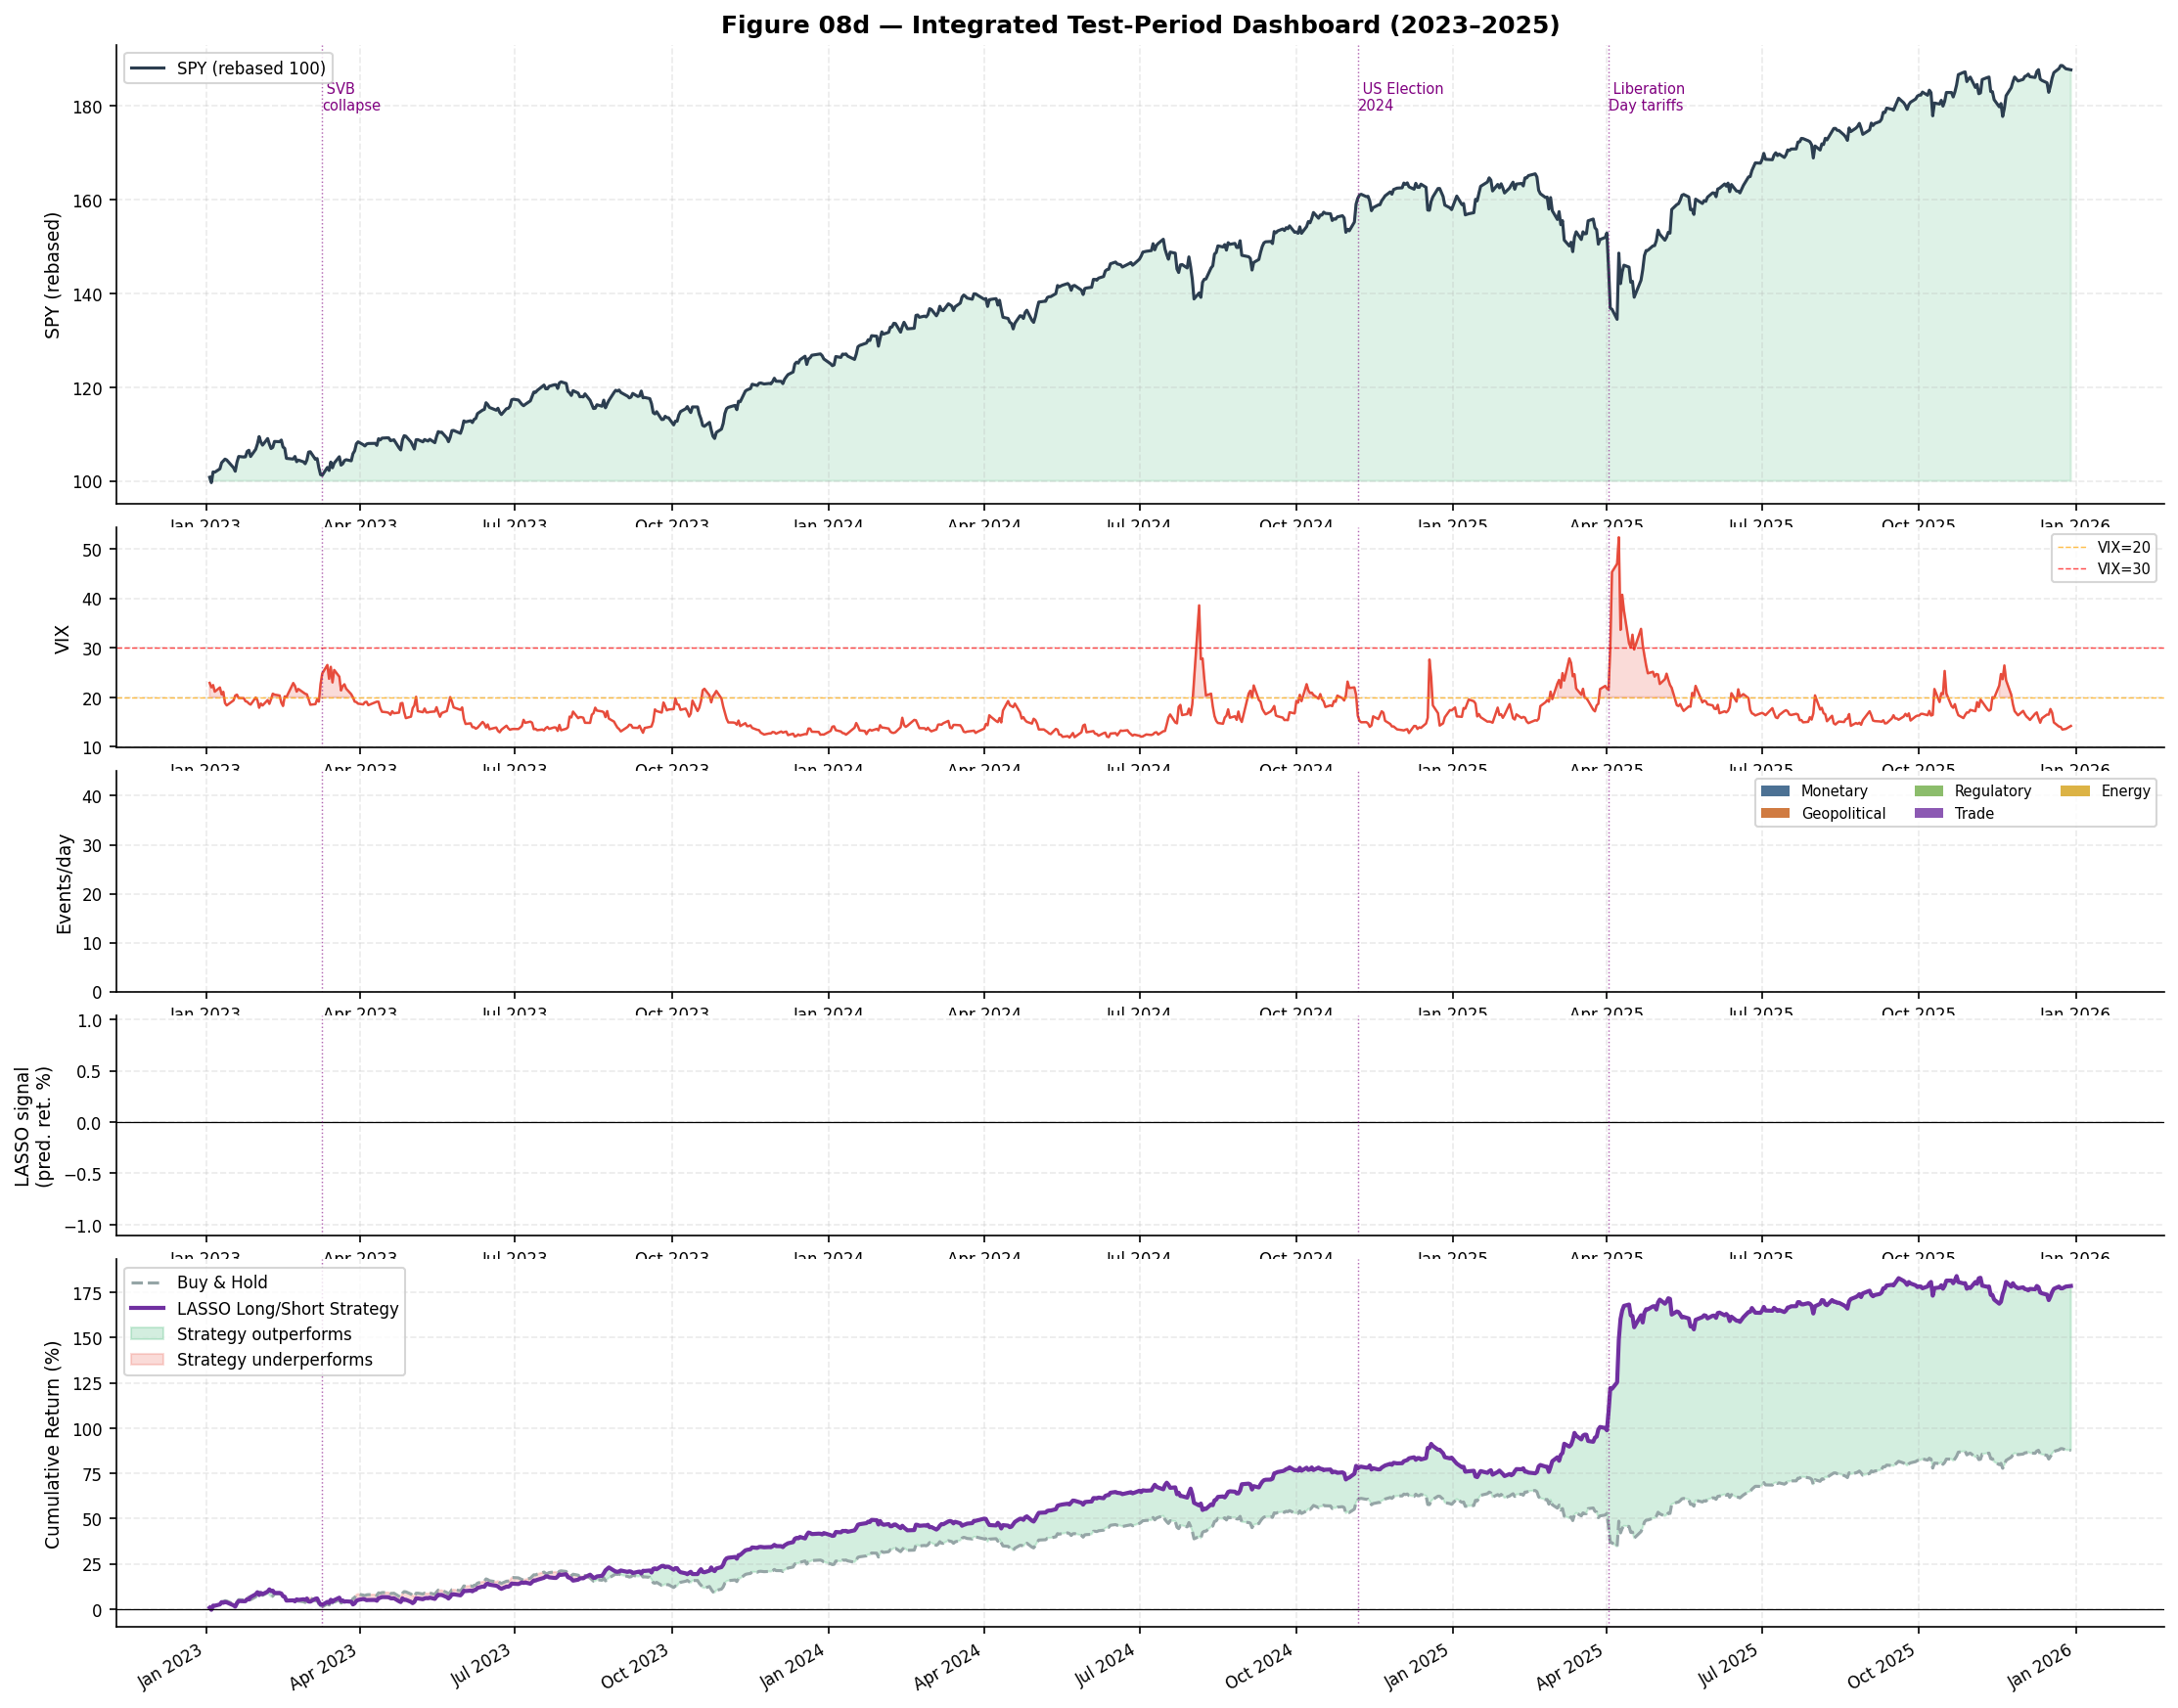

✓ Saved 08d_full_dashboard.png


In [6]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(5, 1, figure=fig, hspace=0.08,
                        height_ratios=[2.5, 1.2, 1.2, 1.2, 2])

# ── Shared x-axis range: full test period ─────────────────────────────────────
test_dates   = preds_df['date'].values
test_feat_df = feat_df[feat_df['date'] > TRAIN_CUT].copy().reset_index(drop=True)
test_feat_df['date'] = pd.to_datetime(test_feat_df['date'])

# ── Panel 1: SPY price (reconstructed from log returns) ───────────────────────
ax1 = fig.add_subplot(gs[0])
spy_price_idx = np.exp(np.cumsum(y_true)) * 100   # normalised to 100
ax1.plot(test_dates, spy_price_idx, color=C['spy'], linewidth=1.5, label='SPY (rebased 100)')
ax1.fill_between(test_dates, spy_price_idx, 100, where=spy_price_idx >= 100,
                 alpha=0.15, color=C['positive'])
ax1.fill_between(test_dates, spy_price_idx, 100, where=spy_price_idx < 100,
                 alpha=0.15, color=C['negative'])
ax1.set_ylabel('SPY (rebased)', fontsize=9)
ax1.legend(loc='upper left', fontsize=8)
ax1.set_xticklabels([])
ax1.set_title('Figure 08d — Integrated Test-Period Dashboard (2023–2025)', fontsize=12, fontweight='bold')

# ── Panel 2: VIX ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
vix_ser = test_feat_df.set_index('date')['vix'].reindex(pd.to_datetime(test_dates), method='ffill')
ax2.plot(test_dates, vix_ser.values, color=C['vix'], linewidth=1.2)
ax2.axhline(20, color='orange', linewidth=0.7, linestyle='--', alpha=0.7, label='VIX=20')
ax2.axhline(30, color='red', linewidth=0.7, linestyle='--', alpha=0.7, label='VIX=30')
ax2.fill_between(test_dates, vix_ser.values, 20,
                 where=vix_ser.values > 20, alpha=0.2, color=C['vix'])
ax2.set_ylabel('VIX', fontsize=9)
ax2.legend(loc='upper right', fontsize=7)
ax2.set_xticklabels([])

# ── Panel 3: Daily event volume (stacked by type) ────────────────────────────
ax3 = fig.add_subplot(gs[2], sharex=ax1)
test_events = events_df[
    (events_df['date'] > pd.Timestamp(TRAIN_CUT)) &
    (events_df['event_type'].isin(EVENT_ORDER))
].copy()
daily_evt = (
    test_events.groupby(['date','event_type'])
    .size().unstack(fill_value=0)
    .reindex(columns=EVENT_ORDER, fill_value=0)
)
# Reindex to test_dates for alignment
daily_evt = daily_evt.reindex(pd.to_datetime(test_dates), fill_value=0)
bottom_e = np.zeros(len(test_dates))
for et in EVENT_ORDER:
    if et in daily_evt.columns:
        ax3.bar(test_dates, daily_evt[et].values, bottom=bottom_e,
                color=C[et], alpha=0.8, width=1, label=et.capitalize())
        bottom_e += daily_evt[et].values
ax3.set_ylabel('Events/day', fontsize=9)
ax3.legend(loc='upper right', fontsize=7, ncol=3)
ax3.set_xticklabels([])

# ── Panel 4: Model signal (predicted return) ──────────────────────────────────
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.bar(test_dates, y_best * 100,
        color=[C['positive'] if v >= 0 else C['negative'] for v in y_best],
        alpha=0.7, width=1)
ax4.axhline(0, color='black', linewidth=0.6)
ax4.set_ylabel(f'{BEST_MODEL} signal\n(pred. ret. %)', fontsize=9)
ax4.set_xticklabels([])

# ── Panel 5: Cumulative strategy return vs buy-and-hold ──────────────────────
ax5 = fig.add_subplot(gs[4], sharex=ax1)
strategy_daily = np.sign(y_best) * y_true
cum_strat = (np.exp(np.cumsum(strategy_daily)) - 1) * 100
cum_bh    = (np.exp(np.cumsum(y_true)) - 1) * 100

ax5.plot(test_dates, cum_bh,    color=C['bh'],       linewidth=1.5,
         linestyle='--', label='Buy & Hold')
ax5.plot(test_dates, cum_strat, color=C['strategy'],  linewidth=2,
         label=f'{BEST_MODEL} Long/Short Strategy')
ax5.fill_between(test_dates, cum_strat, cum_bh,
                 where=cum_strat >= cum_bh, alpha=0.2, color=C['positive'],
                 label='Strategy outperforms')
ax5.fill_between(test_dates, cum_strat, cum_bh,
                 where=cum_strat < cum_bh, alpha=0.2, color=C['negative'],
                 label='Strategy underperforms')
ax5.axhline(0, color='black', linewidth=0.6)
ax5.set_ylabel('Cumulative Return (%)', fontsize=9)
ax5.legend(loc='upper left', fontsize=8)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax5.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

# ── Annotate key events ───────────────────────────────────────────────────────
key_events = [
    (pd.Timestamp('2023-03-10'), 'SVB\ncollapse', ax1),
    (pd.Timestamp('2024-11-06'), 'US Election\n2024', ax1),
    (pd.Timestamp('2025-04-02'), 'Liberation\nDay tariffs', ax1),
]
test_min, test_max = pd.Timestamp(test_dates.min()), pd.Timestamp(test_dates.max())
for ts, label, ax in key_events:
    if test_min <= ts <= test_max:
        for a in [ax1, ax2, ax3, ax4, ax5]:
            a.axvline(ts, color='purple', linewidth=0.7, linestyle=':', alpha=0.6)
        ax1.text(ts, ax1.get_ylim()[1] * 0.96, f' {label}',
                 fontsize=7, color='purple', va='top')

plt.savefig(FIGS / '08d_full_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved 08d_full_dashboard.png')

---
## Section 5 — Summary & Figure Index

In [8]:
print('=' * 65)
print('PHASE 8 — RESULTS VISUALISATION: COMPLETE')
print('=' * 65)

print('\nPUBLICATION FIGURES (300 dpi) → reports/figures/')
figures = [
    ('08a_event_landscape.png',    'Event Landscape',     'Event volume, type mix, sentiment & president breakdown'),
    ('08b_causal_evidence.png',    'Causal Evidence',     'CAR violin, DoWhy CI, sentiment scatter, VIX regime'),
    ('08c_predictive_pipeline.png','Predictive Pipeline', 'Feature groups, top features, SHAP, model comparison'),
    ('08d_full_dashboard.png',     'Full Dashboard',      'SPY + VIX + events + signal + strategy (2023–2025)'),
]
for fname, title, desc in figures:
    path = FIGS / fname
    size = f'{path.stat().st_size / 1024:.0f} KB' if path.exists() else 'MISSING'
    print(f'  {fname:<38} [{size:>8}]  {desc}')

print('\nCOMPLETE FIGURE INVENTORY (all phases):')
all_figs = sorted(FIGS.glob('0*.png'))
for p in all_figs:
    print(f'  {p.name}')

print(f'\nPROJECT STATUS:')
phases = [
    ('01', 'Data Collection',      '✅'),
    ('02', 'EDA',                  '✅'),
    ('03', 'Event Detection',      '✅'),
    ('04', 'Causal Analysis',      '✅'),
    ('05', 'Feature Engineering',  '✅'),
    ('06', 'Model Training',       '✅'),
    ('07', 'Model Evaluation',     '✅'),
    ('08', 'Results Visualisation','✅'),
]
for num, name, status in phases:
    print(f'  Phase {num}: {name:<25} {status}')


PHASE 8 — RESULTS VISUALISATION: COMPLETE

PUBLICATION FIGURES (300 dpi) → reports/figures/
  08a_event_landscape.png                [  581 KB]  Event volume, type mix, sentiment & president breakdown
  08b_causal_evidence.png                [  574 KB]  CAR violin, DoWhy CI, sentiment scatter, VIX regime
  08c_predictive_pipeline.png            [  578 KB]  Feature groups, top features, SHAP, model comparison
  08d_full_dashboard.png                 [  791 KB]  SPY + VIX + events + signal + strategy (2023–2025)

COMPLETE FIGURE INVENTORY (all phases):
  01_correlation_analysis.png
  01_gdelt_distributions.png
  01_price_history.png
  01_vix.png
  02a_normalised_prices.png
  02b_return_distributions.png
  02c_rolling_volatility.png
  02d_vix_series.png
  02e_macro_indicators.png
  02f_return_vix_corr.png
  02g_app_doc_distribution.png
  02h_app_by_president.png
  02i_docs_vs_returns.png
  02j_fomc_distribution.png
  02k_fomc_event_window.png
  02l_combined_timeline.png
  03a_sentiment_di